IMPORT NECESSARY LIBRARIES

In [98]:
import pandas as pd
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

LOADING DATASET

In [101]:
df = pd.read_csv("Output/PreparedData.csv")

In [102]:
with open('../Data/FinalDataset/CategorizedTags.json') as f:
    category_mapping = json.load(f)

In [103]:
with open('../Data/FinalDataset/CategorizedTags.json', 'r') as f:
    category_mapping = json.load(f)
    
print("Category-Tag Mapping Preview:")
for category, tags in category_mapping.items():
    print(f"{category}: {tags[:3]}...")
    

Category-Tag Mapping Preview:
Adventure: ['adventure', 'camping', 'canyoning']...
Nature: ['agriculture field', 'agriculture tourism', 'hills']...
Cultural: ['buddhist pilgrimage', 'community organization', 'festival']...
Historical: ['buddha statue', 'cultural landmarks', 'memorial site']...
Recreational: ['aquarium', 'dining venue', 'dining']...
Religious: ['buddhist culture', 'buddhist heritage', 'buddhist pilgrimage']...
Miscellaneous: ['business', 'business hub', 'economic center']...


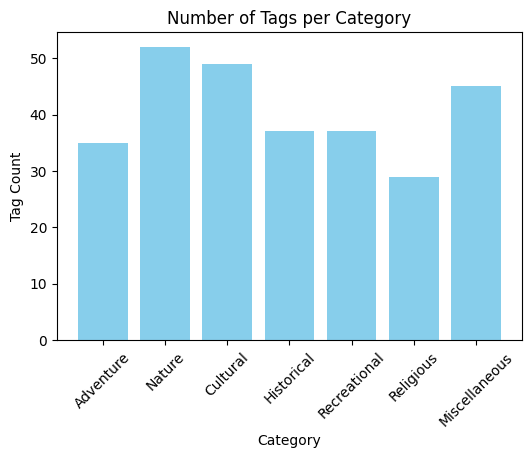

In [106]:
category_counts = {k: len(v) for k, v in category_mapping.items()}
plt.figure(figsize=(6,4))
plt.bar(category_counts.keys(), category_counts.values(), color='skyblue')
plt.title('Number of Tags per Category')
plt.xlabel('Category')
plt.ylabel('Tag Count')
plt.xticks(rotation=45)
plt.show()

CATEGORIZE TAGS

In [107]:
def categorize_tags(tags_str, category_mapping):
    categorized = {}
    tags = [tag.strip().lower().rstrip('.') for tag in tags_str.split(",")]
    
    for category, valid_tags in category_mapping.items():
        valid_tags = [t.lower() for t in valid_tags]
        matched = [tag for tag in tags if tag in valid_tags]
        
        # Feature safety: Ensure minimum 5 unique terms
        if len(matched) < 5:
            dummy_count = 5 - len(matched)
            matched += [f"no_{category}_{i}" for i in range(1, dummy_count + 1)]
            
        categorized[category] = " ".join(matched[:10])  # Limit for efficiency
        
    return categorized

FEATURE ENGINEERING PIPELINE 

In [108]:
df['categorized_tags'] = df['Tags'].apply(lambda x: categorize_tags(x, category_mapping))
for category in category_mapping:
    df[category] = df['categorized_tags'].apply(lambda x: x[category])

PIPELINE FOR PROVINCE [ONE-HOT ENCODING]

In [110]:
province_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

PIPELINE FOR EACH TAG CATEGORY (TF-IDF + DIMESNSIONALITY REDUCTION)

In [111]:
def get_category_pipeline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_features=50,
            stop_words='english'
        )),
        ("svd", TruncatedSVD(n_components=5, random_state=42))
    ])

COMBINING ALL THE PIPELINE USING COLUMN TRANSFORMER

In [113]:
preprocessor = ColumnTransformer([
    ("province", province_pipeline, ["Province"]),
    *[(f"{category}", get_category_pipeline(), f"{category}") 
      for category in category_mapping]
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler())
])

GENERATE FEATURES

In [114]:
X = pipeline.fit_transform(df[["Province"] + list(category_mapping.keys())])

c:\Users\sussh\Documents\CODES\Python\Tourist-Attraction-Recommendation-System\.venv\Lib\site-packages\sklearn\decomposition\_truncated_svd.py:273: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = exp_var / full_var


RECOMMENDATION FUNCTION WITH PROVINCE WEIGHTING

In [115]:
def get_recommendations(target_idx, X, top_n=5):
    # Apply province weighting (3x)
    province_encoder = pipeline.named_steps['preprocessor'].transformers_[0][1]
    province_features = province_encoder.get_feature_names_out()
    province_dim = len(province_features)
    X_weighted = X.copy()
    X_weighted[:, :province_dim] *= 3
    
    # Calculate similarity
    similarity_scores = cosine_similarity(X_weighted[target_idx].reshape(1, -1), X_weighted)
    similar_indices = similarity_scores.argsort()[0][-top_n-1:-1][::-1]
    
    return df.iloc[similar_indices]

In [116]:
print("Top 5 recommendations:")
print(get_recommendations(0, X))

# Save pipeline
joblib.dump(pipeline, "recommendation_pipeline.pkl")

Top 5 recommendations:
    ID                      Name  \
1    2           Mayadevi Temple   
9   10          55-Window Palace   
22  23     Aakash Bhairab Mandir   
19  20       Aadipadma Mahavihar   
18  19  Aadeshwar Mahadev Temple   

                                          Description          Province  \
1   religious site the mayadevi temple is situated...  Lumbini Province   
9   the 55window palace also known a pachpanna jhy...  Bagmati Province   
22  the akash bhairav temple is a significant reli...  Bagmati Province   
19  aadipadma mahavihar is a prominent buddhist mo...  Bagmati Province   
18  the ancient adeshwar mahadev temple is a rever...  Bagmati Province   

                                          Tags  \
1                          buddhist pilgrimage   
9                            historical palace   
22  hindutemplepilgrimagecultural significance   
19        historicalculturalbuddhist monastery   
18      hindutemplepilgrimagehistorical beauty   

        

['recommendation_pipeline.pkl']